In [230]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

In [231]:
market = ADatabase("market")

In [232]:
factors = [str(i) for i in range(10)]

In [233]:
market.connect()
prices = market.query("futures",{"ticker":"BTC-PERP-INTX"})
market.disconnect()

In [234]:
prices

,start,low,high,open,close,volume,ticker
0,1708653300,51358.7,51369.6,51358.7,51369.6,0.5647,BTC-PERP-INTX
1,1708653240,51349,51357.1,51349,51357.1,0.9366,BTC-PERP-INTX
2,1708653180,51320.3,51348.9,51334.8,51348.9,2.7986,BTC-PERP-INTX
3,1708653120,51345.1,51364.6,51364.6,51345.1,1.4222,BTC-PERP-INTX
4,1708653060,51359.4,51369.5,51369.5,51367.2,3.8721,BTC-PERP-INTX
...,...,...,...,...,...,...,...
198436,1694830020,26683,26686.4,26683.1,26684.2,1.9848,BTC-PERP-INTX
198437,1694829960,26678.2,26680.4,26678.9,26680.4,1.7079,BTC-PERP-INTX
198438,1694829900,26678.9,26681.8,26681.8,26678.9,0.6981,BTC-PERP-INTX
198439,1694829840,26678.6,26685.6,26678.6,26681.8,1.7451,BTC-PERP-INTX


In [235]:
prices["date"] = [datetime.fromtimestamp(float(x)) for x in prices["start"]]
prices.sort_values("date",inplace=True)
prices["close"] = [float(x) for x in prices["close"]]
for i in range(10):
    prices[str(i)] = prices["close"].shift(i)
prices["y"] = prices["close"].shift(-60)
prices.dropna(inplace=True)
training = prices.iloc[:-20000]
predictions = prices.iloc[-20000:]
model = XGBRegressor()
model.fit(training[factors],training["y"])
predictions["prediction"] =  model.predict(predictions[factors])
prices = predictions[["date","close","prediction"]].copy()
prices["rolling"] = prices["close"].rolling(30).mean()
prices["return"] = prices["close"].pct_change()
prices["signal"] = prices["rolling"] > prices["close"]
# prices["signal"] = prices["prediction"] > prices["close"]
prices["signal"] = [1 if x == True else - 1 for x in prices["signal"]]

C:\Users\eric\AppData\Local\Temp\ipykernel_7192\2165969331.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions["prediction"] =  model.predict(predictions[factors])


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:06<00:00, 2964.39it/s]


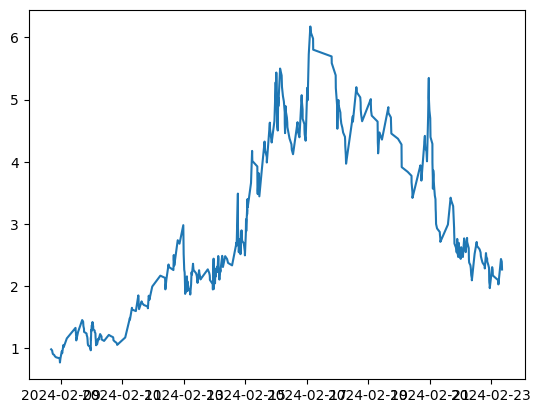

In [245]:
state = {
    "filled":False,
    "signal":0,
    "buy_price":0,
    "sell_price":0
}
profittake = 0.005
stoploss = 0.001
callback = .001
leverage = 15
states = []
for date in tqdm(prices["date"][-20000:]):
    current_market = prices[prices["date"]==date] 
    current_price = current_market["close"].item()
    asset_return = current_market["return"].item()
    signal = current_market["signal"].item()
    if state["filled"]==False:
        state["signal"] = signal
        state["buy_price"] = current_price
        state["sell_price"] = current_price
        state["buy_date"] = date
        state["filled"] = True
    else:
        returns = state["signal"] * (current_price - state["buy_price"]) / state["buy_price"]
        if (asset_return * state["signal"] < -callback and returns > profittake) or returns < -stoploss:
            state["sell_price"] = current_price
            state["sell_date"] = date
            states.append(state.copy())
            state = {
                "filled":False,
                "signal":0,
                "buy_price":0,
                "sell_price":0
            }
trades = pd.DataFrame(states)
trades["return"] = ((trades["sell_price"] - trades["buy_price"]) / trades["buy_price"] * leverage * trades["signal"] + 1)
trades["cr"] = trades["return"].cumprod()
plt.plot(trades["sell_date"].values,trades["cr"].values)
plt.show()